# EccoPy-2D-V Workflow

EccoPy-2D-V classifies a **2-D vertical cross-section** (Z x X — e.g. an
RHI scan, a vertical transect through a storm) into echo type. If you
also supply `height`, `melt`, and `temp` fields, it further
sub-classifies into Stratiform Low/Mid/High and Convective
Shallow/Mid/Deep/Elevated (9 codes total, instead of the basic 3).

This notebook is self-contained (synthetic data, no external files) and
walks through:

1. Generating a synthetic vertical cross-section
2. Basic classification (no height/melt/temp)
3. Sub-classification (with height/melt/temp)
4. `WindowSpec` and `kernel_mode` for a 2-D array
5. `TextureParams` and `ClassificationParams`
6. Debugging with `return_intermediates=True` (including `echo_basic`)
7. Statistics with `eccopy.stats`, including height/depth stats
8. Plotting with `plot_result()` and EccoPy's colormaps


In [1]:
import sys
from pathlib import Path

# Walk up from the notebook's location until we find the directory
# containing the `eccopy` package folder, then add it to sys.path.
here = Path.cwd()
for candidate in [here, *here.parents]:
    if (candidate / "eccopy").is_dir():
        sys.path.insert(0, str(candidate))
        break

import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
np.set_printoptions(precision=3, suppress=True)


In [2]:
from eccopy import eccopy2d_v, stats
from eccopy.params import WindowSpec, TextureParams, ClassificationParams
from eccopy.eccopy2d_v.plot import plot_result
from eccopy.core.colormaps import (
    basic_echo_type_cmap, basic_echo_type_norm, BASIC_ECHO_TYPE_LABELS,
    echo_type_cmap, echo_type_norm, ECHO_TYPE_LABELS,
    convectivity_cmap, convectivity_norm,
)

## 1. Generate a synthetic vertical cross-section

A (Z, X) = (30, 120) cross-section: a stratiform layer with a bright
band near the melting level, and one convective tower.


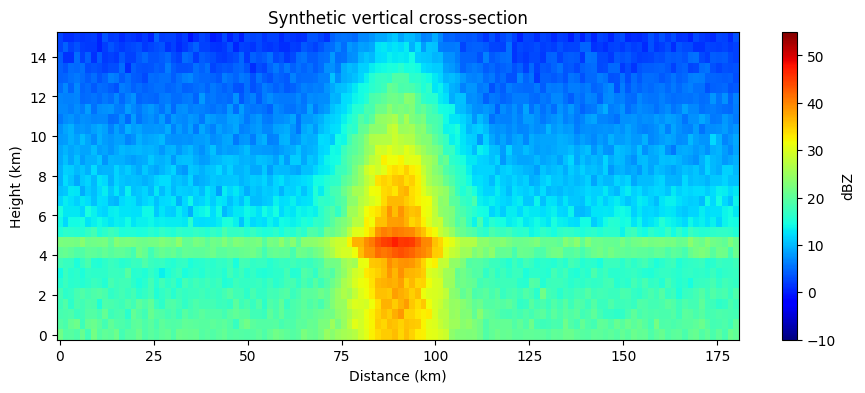

In [3]:
np.random.seed(1)
nz, nx = 30, 120
z_km = np.linspace(0, 15, nz)          # height, km
x_km = np.linspace(0, 180, nx)         # along-track distance, km

# Stratiform background: decreasing with height, bright band near 4.5 km
dbz = 20 - 1.2 * z_km[:, None] + np.random.normal(0, 1.0, (nz, nx))
melt_level_km = 4.5
bright_band = 8 * np.exp(-0.5 * ((z_km - melt_level_km) / 0.4) ** 2)
dbz += bright_band[:, None]

# One convective tower centered at x=90 km, extending through the depth
xx, zz = np.meshgrid(x_km, z_km)
tower = 25 * np.exp(-0.5 * (((xx - 90) / 10) ** 2 + ((zz - 6) / 6) ** 2))
dbz += tower
dbz = np.clip(dbz, -20, 60)

fig, ax = plt.subplots(figsize=(11, 4))
pc = ax.pcolormesh(x_km, z_km, dbz, cmap="jet", vmin=-10, vmax=55, shading="auto")
plt.colorbar(pc, ax=ax, label="dBZ")
ax.set(xlabel="Distance (km)", ylabel="Height (km)", title="Synthetic vertical cross-section")
plt.show()

## 2. Basic classification (no height/melt/temp)

Without `height`/`melt`/`temp`, `run()` returns only the basic 3-code
classification (1=Stratiform, 2=Mixed, 3=Convective).


Codes present: [np.int64(1)]


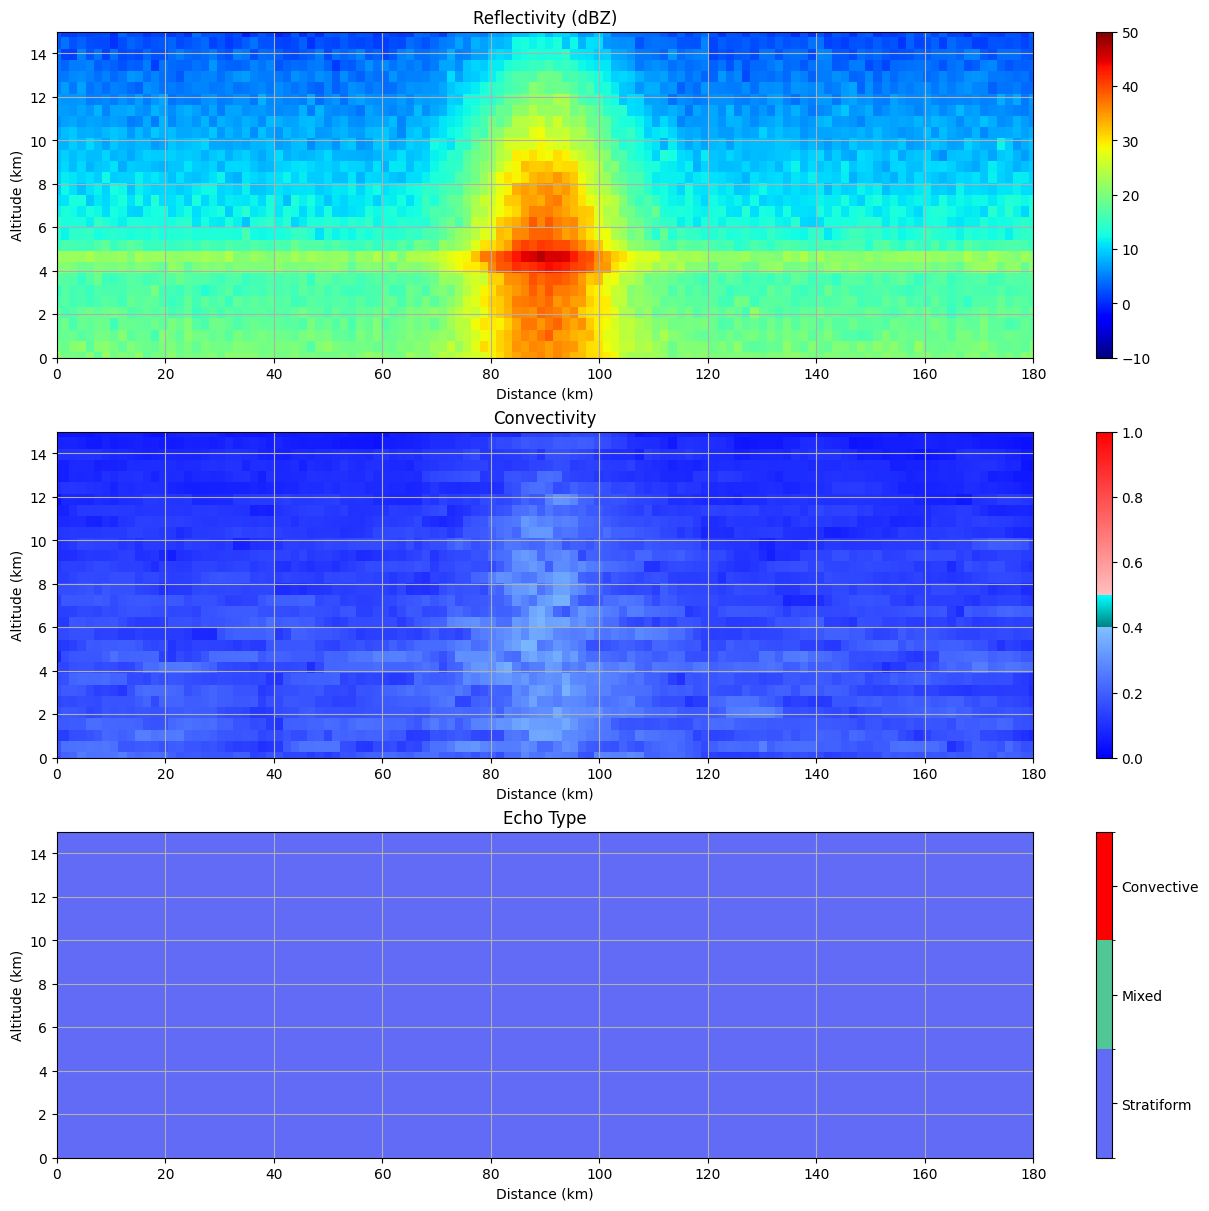

In [4]:
window = WindowSpec((5, "km"))
r_basic = eccopy2d_v.run(dbz, coords_z=z_km, coords_x=x_km, window=window)

print("Codes present:", sorted(np.unique(r_basic.echo_type[~np.isnan(r_basic.echo_type)]).astype(int)))
fig = plot_result(r_basic, dbz, coords_z=z_km, coords_x=x_km)

## 3. Sub-classification (with height/melt/temp)

Passing `height`, `melt`, **and** `temp` together (all three, or none —
see the module docstring's "API CHANGE" note) triggers sub-classification
into 9 codes: Strat Low/Mid/High, Mixed, Conv Elevated/Shallow/Mid/Deep.

Sub-classification uses melt-field proximity (threshold 15) as the
primary signal and temperature (threshold -25 °C) to distinguish
mid-level from deep/high echo — these two thresholds are hardcoded
inside the real `f_classSub.m` port and are **not** configurable via
`VerticalParams` (that's an EccoPy-3D-only parameter object).


Codes present: [np.int64(14), np.int64(16), np.int64(18)]


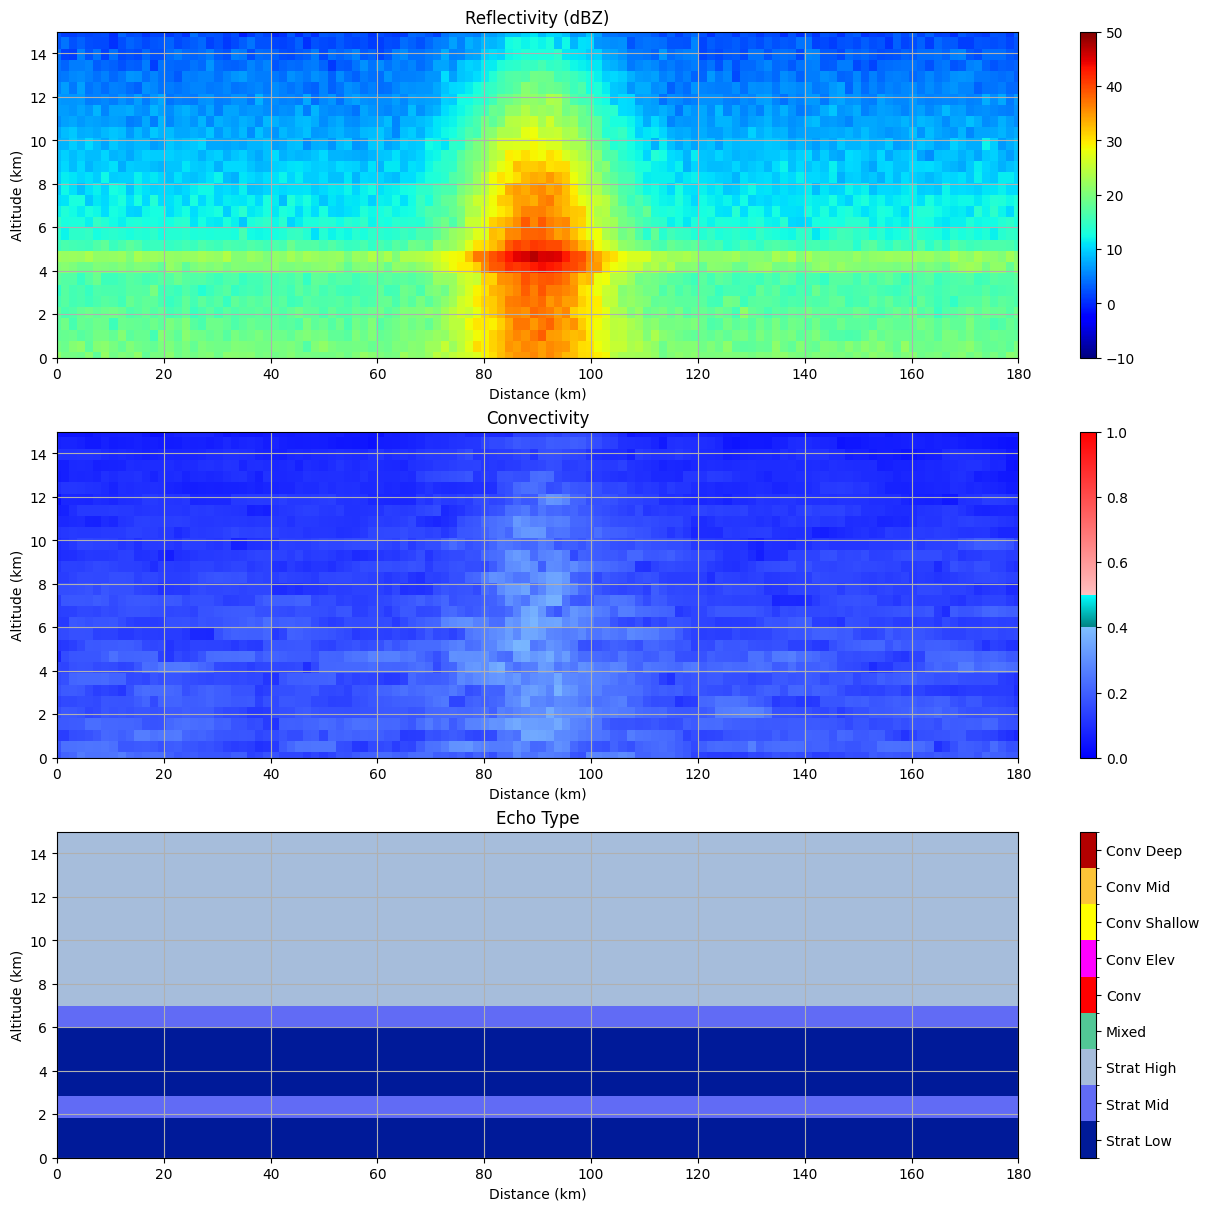

In [5]:
height_field = np.broadcast_to(z_km[:, None], (nz, nx)).astype(float)   # km AGL at every point
# A synthetic melt-proximity field: low near the bright band, high elsewhere
melt_field = np.abs(height_field - melt_level_km) * 10
# A synthetic temperature field: roughly -6.5 C/km lapse rate from a 20 C surface
temp_field = 20 - 6.5 * height_field

r_sub = eccopy2d_v.run(dbz, coords_z=z_km, coords_x=x_km, window=window,
                       height=height_field, melt=melt_field, temp=temp_field)

print("Codes present:", sorted(np.unique(r_sub.echo_type[~np.isnan(r_sub.echo_type)]).astype(int)))
fig = plot_result(r_sub, dbz, coords_z=z_km, coords_x=x_km)

## 4. `WindowSpec` and `kernel_mode`

Same `WindowSpec` semantics as EccoPy-1D, applied along the X axis (last
axis) of the 2-D array. `kernel_mode="varying"` lets each row (or even
each point, if `coords_x` is itself 2-D) resolve its own pixel radius —
useful for e.g. an RHI where along-beam spacing changes with elevation
angle.


In [6]:
r_uniform = eccopy2d_v.run(dbz, coords_z=z_km, coords_x=x_km, window=window, kernel_mode="uniform")
r_varying = eccopy2d_v.run(dbz, coords_z=z_km, coords_x=x_km, window=window, kernel_mode="varying")

# On this uniform-spacing synthetic grid, uniform and varying modes agree exactly:
print("uniform == varying on a uniform grid:",
      np.allclose(r_uniform.texture, r_varying.texture, equal_nan=True))

uniform == varying on a uniform grid: True


## 5. `TextureParams` and `ClassificationParams`

Same fields as EccoPy-1D (see that notebook for the full table) —
`TextureParams.upper_lim_dbz` controls how quickly texture saturates to
convectivity=1, and `ClassificationParams`'s strat/mixed/conv thresholds
and enlarge radii control the basic classification.


In [7]:
cp_tighter = ClassificationParams(max_convectivity_for_stratiform=0.3,
                                  min_convectivity_for_convective=0.6)
r_tighter = eccopy2d_v.run(dbz, coords_z=z_km, coords_x=x_km, window=window, class_params=cp_tighter)

print("Default thresholds -- Conv fraction: %.1f%%" % stats.convective_percentage(r_basic.echo_type))
print("Tighter thresholds -- Conv fraction: %.1f%%" % stats.convective_percentage(r_tighter.echo_type))

Default thresholds -- Conv fraction: 0.0%
Tighter thresholds -- Conv fraction: 0.0%


## 6. Debugging with `return_intermediates=True`

For EccoPy-2D-V this adds `fitted_dbz`, `detrended_dbz` (same meaning as
EccoPy-1D, computed along the X axis) **and** `echo_basic` — the basic
strat/mixed/conv classification *before* sub-classification is applied,
even when `height`/`melt`/`temp` are all given.


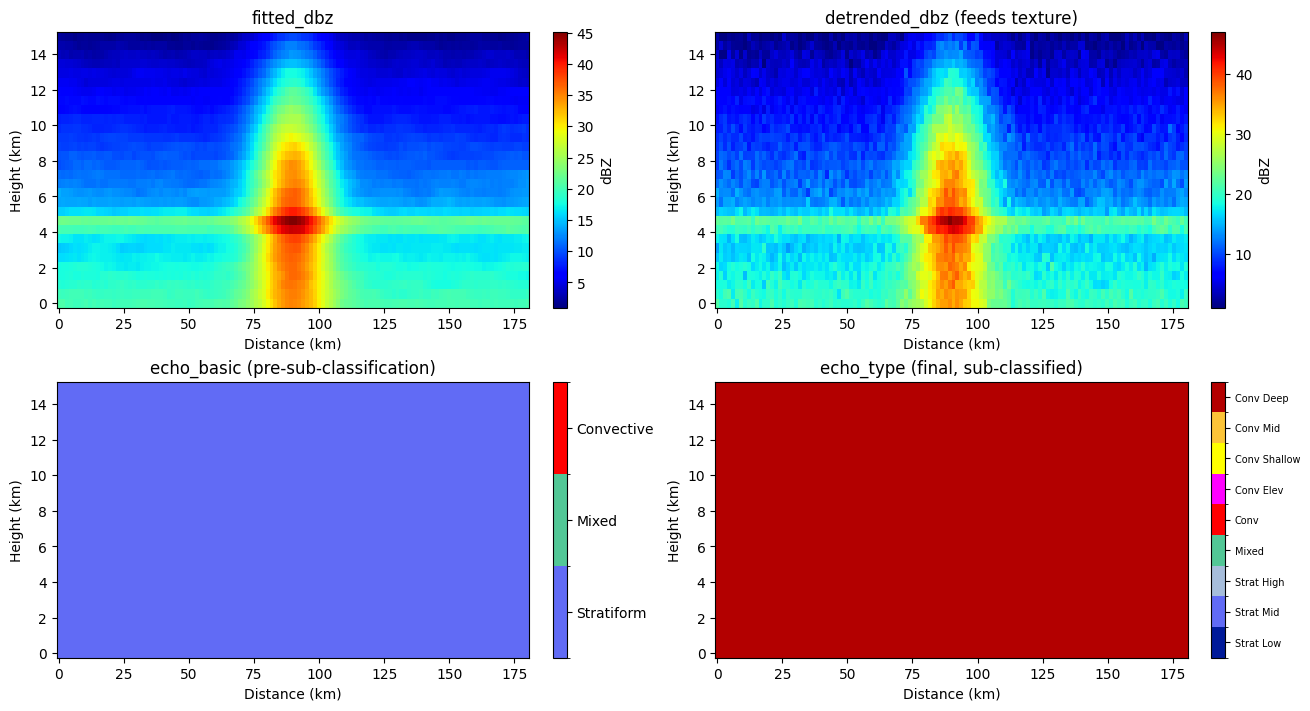

In [8]:
r_debug = eccopy2d_v.run(dbz, coords_z=z_km, coords_x=x_km, window=window,
                         height=height_field, melt=melt_field, temp=temp_field,
                         return_intermediates=True)

fig, axes = plt.subplots(2, 2, figsize=(13, 7), constrained_layout=True)

pc = axes[0, 0].pcolormesh(x_km, z_km, r_debug.fitted_dbz, cmap="jet", shading="auto")
plt.colorbar(pc, ax=axes[0, 0], label="dBZ")
axes[0, 0].set(title="fitted_dbz", xlabel="Distance (km)", ylabel="Height (km)")

pc = axes[0, 1].pcolormesh(x_km, z_km, r_debug.detrended_dbz, cmap="jet", shading="auto")
plt.colorbar(pc, ax=axes[0, 1], label="dBZ")
axes[0, 1].set(title="detrended_dbz (feeds texture)", xlabel="Distance (km)", ylabel="Height (km)")

pc = axes[1, 0].pcolormesh(x_km, z_km, r_debug.echo_basic, cmap=basic_echo_type_cmap(),
                           norm=basic_echo_type_norm(), shading="auto")
cb = plt.colorbar(pc, ax=axes[1, 0], ticks=range(1, 4))
cb.ax.set_yticklabels(BASIC_ECHO_TYPE_LABELS)
axes[1, 0].set(title="echo_basic (pre-sub-classification)", xlabel="Distance (km)", ylabel="Height (km)")

pc = axes[1, 1].pcolormesh(x_km, z_km, r_debug.echo_type, cmap=echo_type_cmap(),
                           norm=echo_type_norm(), shading="auto")
cb = plt.colorbar(pc, ax=axes[1, 1], ticks=range(1, 10))
cb.ax.set_yticklabels(ECHO_TYPE_LABELS, fontsize=7)
axes[1, 1].set(title="echo_type (final, sub-classified)", xlabel="Distance (km)", ylabel="Height (km)")

plt.show()

## 7. Statistics with `eccopy.stats`, including height

With a co-located `height` array, `eccopy.stats` can compute
column-by-column convective top/base/depth in addition to the
coverage/clump statistics from the 1-D notebook.


n_valid: 3600
stratiform: 1.0
mixed: 0.0
convective: 0.0
convective_pct: 0.0
stratiform_pct: 100.0
mixed_pct: 0.0
n_convective_clumps: 0
n_stratiform_clumps: 1
mean_convective_clump_size: nan
mean_convective_top_height: nan
mean_convective_base_height: nan
mean_convective_depth: nan
max_convective_top_height: nan


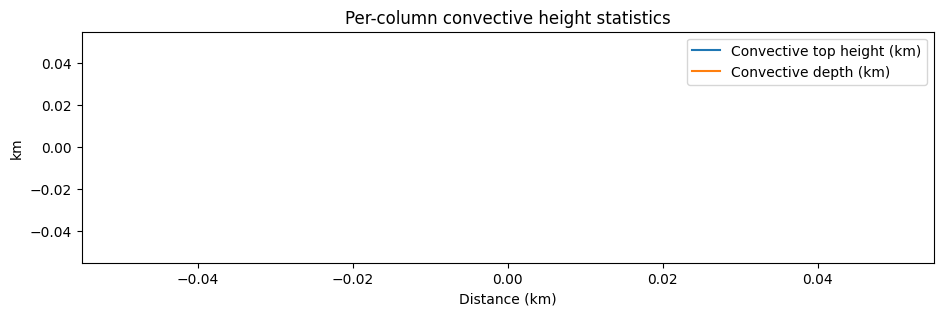

In [9]:
summary = stats.summarize(r_debug.echo_type, height=height_field, axis=0)
for k, v in summary.items():
    if not isinstance(v, np.ndarray):
        print(f"{k}: {v}")

conv_depth = stats.convective_depth(r_debug.echo_type, height_field, axis=0)   # shape (X,)
conv_top = stats.convective_top_height(r_debug.echo_type, height_field, axis=0)

fig, ax = plt.subplots(figsize=(11, 3))
ax.plot(x_km, conv_top, label="Convective top height (km)")
ax.plot(x_km, conv_depth, label="Convective depth (km)")
ax.set(xlabel="Distance (km)", ylabel="km", title="Per-column convective height statistics")
ax.legend()
plt.show()

## 8. Plotting

`plot_result()` (used above) gives a standard 3-panel view. For custom
figures, `eccopy.core.colormaps` provides:

- `basic_echo_type_cmap()`/`norm()` — 3-code results
- `echo_type_cmap()`/`norm()` — 9-code sub-classified results
- `convectivity_cmap()`/`norm()` — convectivity, ramping continuously
  within each class but with **hard breaks** at the two classification
  thresholds (`params.strat_mixed`, default 0.4; `params.mixed_conv`,
  default 0.5), so blue / teal / red map directly onto Stratiform /
  Mixed / Convective. Pass non-default thresholds through as
  `convectivity_cmap(params.strat_mixed, params.mixed_conv)` to keep the
  breaks aligned with the classification.

Both classification colormaps assign the **same color** to their shared
categories (Stratiform <-> Strat Mid, Mixed <-> Mixed, Convective <->
Conv), so switching between a basic-only case and a sub-classified case
reads consistently.


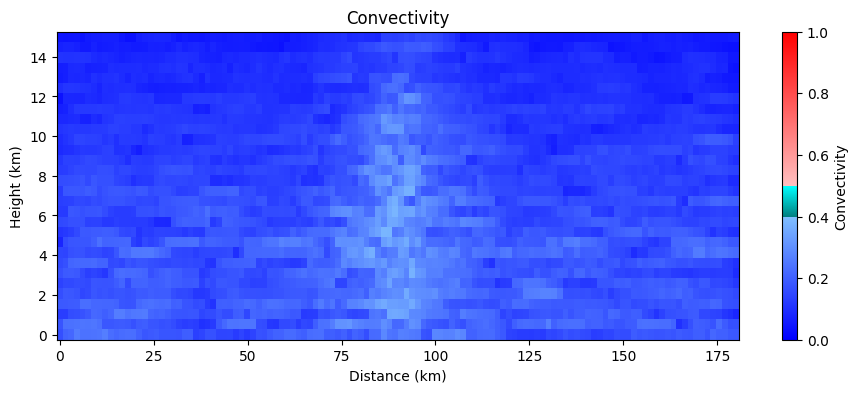

In [10]:
fig, ax = plt.subplots(figsize=(11, 4))
pc = ax.pcolormesh(x_km, z_km, r_debug.convectivity, cmap=convectivity_cmap(),
                   norm=convectivity_norm(), shading="auto")
plt.colorbar(pc, ax=ax, label="Convectivity")
ax.set(xlabel="Distance (km)", ylabel="Height (km)", title="Convectivity")
plt.show()

## Summary

- EccoPy-2D-V returns basic (3-code) classification by default, and
  sub-classification (9-code) when `height`, `melt`, and `temp` are all
  supplied.
- `WindowSpec`/`kernel_mode`/`TextureParams`/`ClassificationParams` work
  the same way as EccoPy-1D, applied along the X axis.
- `return_intermediates=True` additionally exposes `echo_basic`, the
  pre-sub-classification result.
- `eccopy.stats` computes per-column height/depth statistics when given
  a `height` array.

See `eccopy2d_h_workflow.ipynb` next for a single horizontal level /
composite, or `eccopy3d_workflow.ipynb` for the full 3-D volume path.
